# Concordance experiment — scJDO vs SpliceJAC vs Dynamo

**Purpose.** This notebook addresses the deepest skepticism a reviewer can level at scJDO: *is the learned operator real, or an artifact of the neural ODE drift?* To answer it, we compare scJDO's geometry-derived Jacobian against the two prior single-cell Jacobian methods on a dataset where they can all run.

**Framing (for the rebuttal letter).** scJDO and SpliceJAC/Dynamo compute the same kind of object — a local Jacobian whose spectrum encodes local stability. They differ on (i) how the Jacobian is obtained (geometry-derived score matching vs splicing kinetics) and (ii) what we do with it after (continuous temporal tensor + archetype decomposition vs per-state snapshots). The temporal layer is uncontested novelty. The Jacobian itself is *not* unprecedented and concordance with prior methods is the strongest external validation available for it.

**Three concordance tests** (Plan, Tier 1, Item 1):

| # | Question | Metric |
|---|---|---|
| T1 | Do leading-eigenvalue *instability peaks* land at the same states? | Spearman ρ across clusters of `max Re(λ)`; argmax-cluster agreement |
| T2 | Do *unstable eigendirections* overlap in gene space? | Cosine similarity of leading unstable eigenvectors after projecting scJDO via FA loadings |
| T3 | Do *transition-gene lists* agree? | Top-K Jaccard + Spearman rank correlation of per-gene instability ranks |

**Dataset.** `scvelo.datasets.bonemarrow()` — Setty 2019 bone marrow CD34+ scRNA-seq with spliced/unspliced layers. Structural analog to Paul15 hematopoiesis (the system used in the manuscript), and the canonical SpliceJAC / Dynamo testbed.

**Outcome.** Either result is publishable.
- *Concordance* → scJDO's geometry-derived operator recovers what splicing-derived methods see → answers the neural-ODE-artifact skepticism.
- *Divergence + temporal layer adds structure they miss* → demonstrates the advance rather than asserting it.

Cite [Niemiec et al. 2025 bioRxiv](https://www.biorxiv.org/content/10.1101/2025.02.05.636568v1) showing splicing-derived Jacobians are noisy / inconsistent to argue scJDO ≥ SpliceJAC concordance — i.e. ours is at least as well behaved.

**Runtime.** ~10 min on CPU with `QUICK=True`; ~45 min full.

In [1]:
#!pip install dynamo-release


In [2]:
# ── 0. Imports, optional-dependency probe, style ────────────────────────
import os, sys, json, warnings
from pathlib import Path

sys.path.insert(0, os.path.abspath('../..'))
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import torch
import anndata as ad
import scanpy as sc
import scvelo as scv
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
from scipy.stats import spearmanr, rankdata
from scipy.spatial.distance import cosine

from scjdo.tl import fit_drift

# Optional dependencies — probed once, gated on every section that needs them
HAVE_SPLICEJAC = False
HAVE_DYNAMO    = False
try:
    import splicejac as sjac          # noqa: F401
    HAVE_SPLICEJAC = True
except Exception as e:
    print(f'[skip] SpliceJAC not importable ({e}).  Install with: pip install spliceJAC')
try:
    import dynamo as dyn              # noqa: F401
    HAVE_DYNAMO = True
except Exception as e:
    print(f'[skip] dynamo not importable ({e}).  Install with: pip install dynamo-release')

# Manuscript-style rcParams (Nature Methods)
mpl.rcParams.update({
    'pdf.fonttype': 42, 'ps.fonttype': 42, 'font.family': 'DejaVu Sans',
    'font.size': 8, 'axes.titlesize': 10, 'axes.labelsize': 8,
    'xtick.labelsize': 7, 'ytick.labelsize': 7, 'legend.fontsize': 7,
    'axes.linewidth': 0.8,
})

PALETTE = {
    'scjdo':     '#E63946',
    'splicejac': '#2A9D8F',
    'dynamo':    '#457B9D',
    'neutral':   '#1A1A2E',
    'agree':     '#06A77D',
    'disagree':  '#D62828',
}

SEED      = 0
QUICK     = True                       # True → ~10 min CPU run; False → ~45 min
N_EPOCHS  = 800 if QUICK else 3000
N_HVG     = 1500
N_PCS     = 30
TOP_K     = 30                         # transition-gene list size
OUTDIR    = Path('.')
rng = np.random.default_rng(SEED); torch.manual_seed(SEED)
print(f'QUICK={QUICK}  HAVE_SPLICEJAC={HAVE_SPLICEJAC}  HAVE_DYNAMO={HAVE_DYNAMO}')

QUICK=True  HAVE_SPLICEJAC=True  HAVE_DYNAMO=True


## 1. Load splicing-amenable hematopoiesis data

`scvelo.datasets.bonemarrow()` — Setty et al. 2019, CD34+ bone marrow, ~5,780 cells with both `spliced` and `unspliced` layers. Branches: HSC → erythroid / monocyte / DC, structurally identical to Paul15.

In [3]:
adata = scv.datasets.bonemarrow()
print(adata)

# Light preprocessing — uses scvelo's pipeline so splicing layers stay aligned
scv.pp.filter_and_normalize(adata, min_shared_counts=20)
scv.pp.moments(adata, n_pcs=N_PCS, n_neighbors=30)
sc.tl.diffmap(adata, n_comps=15)

# Cluster labels (resolved a few lines below) — pick the HSC cluster cell
# with the highest CD34 expression as the iroot, otherwise the highest-CD34
# cell overall. sc.tl.dpt silently does nothing without iroot, which is the
# bug that produced the empty PDF.
_label_col_tmp = next((c for c in ['clusters','celltype','cell_type','leiden']
                        if c in adata.obs), None)
_hsc_mask = (adata.obs[_label_col_tmp].astype(str).str.startswith('HSC')
             if _label_col_tmp is not None
             else np.ones(adata.n_obs, bool))
if 'CD34' in adata.var_names:
    _cd34 = np.asarray(adata[:, 'CD34'].X.todense()).ravel() \
            if hasattr(adata.X, 'todense') else np.asarray(adata[:, 'CD34'].X).ravel()
elif 'Cd34' in adata.var_names:
    _cd34 = np.asarray(adata[:, 'Cd34'].X.todense()).ravel() \
            if hasattr(adata.X, 'todense') else np.asarray(adata[:, 'Cd34'].X).ravel()
else:
    _cd34 = np.zeros(adata.n_obs)
# Prefer an HSC cell; fall back to highest-CD34 overall if HSC mask is empty.
if _hsc_mask.any() and _cd34.max() > 0:
    _hsc_idx = np.flatnonzero(_hsc_mask)
    adata.uns['iroot'] = int(_hsc_idx[np.argmax(_cd34[_hsc_idx])])
elif _cd34.max() > 0:
    adata.uns['iroot'] = int(np.argmax(_cd34))
else:
    adata.uns['iroot'] = 0
print(f'iroot set to cell {adata.uns["iroot"]} '
      f'(cluster={adata.obs[_label_col_tmp].iloc[adata.uns["iroot"]] if _label_col_tmp else "n/a"}, '
      f'CD34={_cd34[adata.uns["iroot"]]:.2f})')

sc.tl.dpt(adata)
if 'dpt_pseudotime' not in adata.obs:
    raise RuntimeError('DPT did not produce dpt_pseudotime — check iroot/diffmap.')
adata.obs['pseudotime'] = adata.obs['dpt_pseudotime'].astype(float)
pt = adata.obs['pseudotime'].to_numpy()
adata.obs['pseudotime'] = ((pt - np.nanmin(pt)) /
                            (np.nanmax(pt) - np.nanmin(pt) + 1e-9)).astype(np.float32)

# Cluster labels — for per-cluster Jacobian comparison.
# Use existing annotations if present, otherwise compute Leiden.
label_col = next((c for c in ['clusters', 'celltype', 'cell_type', 'leiden']
                  if c in adata.obs), None)
if label_col is None:
    sc.tl.leiden(adata, resolution=0.6, key_added='leiden')
    label_col = 'leiden'
adata.obs['cluster'] = adata.obs[label_col].astype('category')
print(f'{adata.n_obs} cells, {adata.n_vars} genes, label_col={label_col!r}, '
      f'clusters={adata.obs["cluster"].cat.categories.tolist()}')

AnnData object with n_obs × n_vars = 5780 × 14319
    obs: 'clusters', 'palantir_pseudotime'
    uns: 'clusters_colors'
    obsm: 'X_tsne'
    layers: 'spliced', 'unspliced'


Filtered out 7837 genes that are detected 20 counts (shared).
Normalized count data: X, spliced, unspliced.
Logarithmized X.


/Users/terooatt/miniconda3/lib/python3.13/site-packages/scvelo/preprocessing/utils.py:705: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  log1p(adata)
/var/folders/8q/0m_1_8yj0r1_hxyz4br3vg4r0000gp/T/ipykernel_45048/1234513679.py:6: DeprecationWarning: Automatic neighbor calculation is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors first with Scanpy.
  scv.pp.moments(adata, n_pcs=N_PCS, n_neighbors=30)
/Users/terooatt/miniconda3/lib/python3.13/site-packages/scvelo/preprocessing/moments.py:71: DeprecationWarning: `neighbors` is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors with Scanpy.
  neighbors(
/Users/terooatt/miniconda3/lib/python3.13/site-packages/scvelo/preprocessing/neighbors.py:233: DeprecationWarning: Automatic computation of PCA is deprecated since scvelo=

computing neighbors


    finished (0:00:00) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities


    finished (0:00:01) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
iroot set to cell 1722 (cluster=HSC_1, CD34=1.82)
5780 cells, 6482 genes, label_col='clusters', clusters=['HSC_1', 'HSC_2', 'Ery_1', 'Mono_1', 'Precursors', 'CLP', 'Mono_2', 'DCs', 'Ery_2', 'Mega']


## 2. Run scJDO — per-window tensor *and* per-cluster Jacobians at centroids

scJDO's native output is a per-window Jacobian tensor `J ∈ R^(T × d × d)` along pseudotime. To enable like-for-like comparison with SpliceJAC's per-cluster Jacobians, we additionally evaluate the trained drift field at each cluster's mean latent state and time, then differentiate via autograd.

In [4]:
model = fit_drift(
    adata, rep='X_pca', time_key='pseudotime',
    n_epochs=N_EPOCHS, n_archetypes=4,
    vel_scale=2.0, seed=SEED, verbose=False,
)
res = adata.uns['scjdo']
print(f'fit_drift done | R²={res["r2"]:.3f} | latent dim={adata.obsm["X_pca"].shape[1]}')

def jacobian_at(model, x, t):
    """∂f/∂x evaluated at one point (x in latent space, t scalar in [0,1])."""
    x = torch.tensor(x, dtype=torch.float32, requires_grad=True).reshape(1, -1)
    t = torch.tensor([float(t)], dtype=torch.float32)
    f = model(x, t).reshape(-1)
    J = torch.stack([torch.autograd.grad(f[i], x, retain_graph=True)[0].reshape(-1)
                     for i in range(f.shape[0])])
    return J.detach().numpy()

X_lat = adata.obsm['X_pca']
t_all = adata.obs['pseudotime'].to_numpy()
clusters = adata.obs['cluster'].cat.categories.tolist()

scjdo_J_per_cluster   = {}      # cluster -> (d, d)
scjdo_inst_per_cluster = {}     # cluster -> scalar max Re(λ)
scjdo_vec_per_cluster  = {}     # cluster -> leading unstable eigenvector in latent space
for c in clusters:
    sel = (adata.obs['cluster'] == c).to_numpy()
    if sel.sum() < 5:
        continue
    x_c = X_lat[sel].mean(0)
    t_c = float(np.nanmean(t_all[sel]))
    Jc  = jacobian_at(model, x_c, t_c)
    w, V = np.linalg.eig(Jc)
    k = int(np.argmax(w.real))
    scjdo_J_per_cluster[c]    = Jc
    scjdo_inst_per_cluster[c] = float(w[k].real)
    scjdo_vec_per_cluster[c]  = V[:, k].real / (np.linalg.norm(V[:, k].real) + 1e-12)

if not scjdo_inst_per_cluster:
    raise RuntimeError('scJDO produced no per-cluster Jacobians. '
                       'Check that every cluster has >=5 cells and that '
                       'fit_drift trained successfully.')
print(pd.Series(scjdo_inst_per_cluster).sort_values(ascending=False).round(3))

fit_drift done | R²=0.999 | latent dim=30
CLP           0.353
DCs           0.314
HSC_1         0.301
Mega          0.292
Mono_1        0.281
Mono_2        0.238
HSC_2         0.177
Ery_1         0.151
Precursors    0.121
Ery_2         0.096
dtype: float64


In [5]:
# ── 2b. Project scJDO unstable eigenvectors from latent → gene space ─────
# scJDO operates in PCA latent space. SpliceJAC/Dynamo operate in gene space.
# Use PCA loadings (genes × PCs) to map latent eigenvectors back to genes.
if 'PCs' in adata.varm:
    PCs = adata.varm['PCs']                              # (n_var, n_pcs)
else:
    # fall back: compute loadings from sc.tl.pca state
    sc.pp.pca(adata, n_comps=N_PCS)
    PCs = adata.varm['PCs']

# Use the first cluster that actually got a Jacobian (small/edge clusters
# get filtered by the >=5-cell guard in the previous cell).
first_c = next(iter(scjdo_vec_per_cluster))
n_lat   = scjdo_vec_per_cluster[first_c].shape[0]
PCs = PCs[:, :n_lat]

scjdo_gene_vec = {}              # cluster -> gene-space leading unstable direction
scjdo_gene_inst_rank = {}        # cluster -> gene-instability score (|loading|·|eigvec|)
for c, v in scjdo_vec_per_cluster.items():
    g = PCs @ v                                          # (n_var,)
    scjdo_gene_vec[c] = g / (np.linalg.norm(g) + 1e-12)
    scjdo_gene_inst_rank[c] = np.abs(g)                 # per-gene instability magnitude

scjdo_gene_top = {
    c: list(adata.var_names[np.argsort(scjdo_gene_inst_rank[c])[::-1][:TOP_K]])
    for c in scjdo_gene_inst_rank
}
print('scJDO top-5 genes by cluster (first 3 clusters):')
for c in list(scjdo_gene_top)[:3]:
    print(f'  {c:15s} -> {scjdo_gene_top[c][:5]}')

scJDO top-5 genes by cluster (first 3 clusters):
  HSC_1           -> ['TSC22D3', 'ARGLU1', 'CLEC11A', 'RP11-620J15.3', 'SRSF5']
  HSC_2           -> ['NEAT1', 'LAPTM5', 'HLA-C', 'HLA-B', 'BST2']
  Ery_1           -> ['ZFP36L2', 'IGLL1', 'GYPC', 'CLEC11A', 'MYL12B']


## 3. Run SpliceJAC — per-cluster Jacobian from splicing kinetics

SpliceJAC's central object is a per-cluster Jacobian inferred from `(spliced, unspliced)` counts; we read its leading eigenvalue (= per-cluster instability score) and leading unstable eigenvector (= gene-space unstable direction). If SpliceJAC is not installed this section is skipped and the comparison degrades to scJDO vs Dynamo only.

In [6]:
#import sys
#!{sys.executable} -m pip uninstall -y scvelo scanpy plotly pyvis splicejac
#!{sys.executable} -m pip install scvelo==0.2.4 scanpy==1.9.1 plotly==5.10.0 pyvis==0.2.1 splicejac

In [7]:
sjac_inst_per_cluster = {}
sjac_gene_vec         = {}
sjac_gene_top         = {}
sjac_gene_inst_rank   = {}

if HAVE_SPLICEJAC:
    import splicejac as sjac
    adata_sj = adata.copy()
    adata_sj.obs['clusters'] = adata_sj.obs['cluster']    # spliceJAC convention
    try:
        # spliceJAC needs n_top_genes <= size of the smallest cluster
        _min_cluster = int(adata_sj.obs['clusters'].value_counts().min())
        N_TOP_SJAC   = min(50, max(8, _min_cluster - 1))
        print(f'[splicejac] smallest cluster has {_min_cluster} cells; '
              f'using n_top_genes={N_TOP_SJAC}')
        sjac.tl.estimate_jacobian(
            adata_sj, n_top_genes=N_TOP_SJAC, seed=SEED, nsim=10,
        )
        # average_jac[cluster] = [J (G×G concat spliced+unspliced),
        #                        eigenvalues (G,) complex,
        #                        eigenvectors (G,G) complex]
        # G = 2 * N_TOP_SJAC because the linear model is jointly over
        # spliced and unspliced abundance vectors. The first half of every
        # eigenvector is the spliced (expression-space) component.
        ajdict = adata_sj.uns['average_jac']
        sjac_hvg_names = list(adata_sj.var_names[adata_sj.var['highly_variable']])
        G_half = len(sjac_hvg_names)
        all_genes = list(adata.var_names)
        name_to_idx = {g: i for i, g in enumerate(all_genes)}

        for c, payload in ajdict.items():
            if c not in scjdo_inst_per_cluster:
                continue
            J_c, eigvals, eigvecs = payload
            J_c = np.asarray(J_c); eigvals = np.asarray(eigvals)
            eigvecs = np.asarray(eigvecs)
            k = int(np.argmax(eigvals.real))
            sjac_inst_per_cluster[c] = float(eigvals[k].real)

            # Pull the leading eigenvector and aggregate
            # spliced+unspliced components per gene → magnitude.
            v_full = eigvecs[:, k]
            v_spliced  = np.abs(v_full[:G_half])
            v_unspl    = np.abs(v_full[G_half:G_half * 2])
            v_per_gene = v_spliced + v_unspl
            v_per_gene = v_per_gene / (np.linalg.norm(v_per_gene) + 1e-12)

            # Embed into the full gene-name space so it aligns with scJDO's
            # per-gene vectors for cosine-similarity (T2) and Jaccard (T3).
            v_in_full = np.zeros(len(all_genes), dtype=float)
            for gname, mag in zip(sjac_hvg_names, v_per_gene):
                j = name_to_idx.get(gname)
                if j is not None:
                    v_in_full[j] = float(mag)
            sjac_gene_vec[c]       = v_in_full / (np.linalg.norm(v_in_full) + 1e-12)
            sjac_gene_inst_rank[c] = np.abs(v_in_full)
            top_idx = np.argsort(v_in_full)[::-1][:TOP_K]
            sjac_gene_top[c] = [all_genes[j] for j in top_idx if v_in_full[j] > 0]

        print('\nSpliceJAC per-cluster max Re(λ):')
        print(pd.Series(sjac_inst_per_cluster).sort_values(ascending=False).round(3))
    except Exception as e:
        import traceback; traceback.print_exc()
        print(f'[warn] SpliceJAC run failed: {e!r}')
        HAVE_SPLICEJAC = False
else:
    print('SpliceJAC not available — section skipped.')


[splicejac] smallest cluster has 61 cells; using n_top_genes=50


Filtered out 387 genes that are detected 20 counts (shared).
Extracted 50 highly variable genes.


Logarithmized X.
Running quick regression...


/Users/terooatt/miniconda3/lib/python3.13/site-packages/scvelo/preprocessing/utils.py:705: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  log1p(adata)
/Users/terooatt/miniconda3/lib/python3.13/site-packages/splicejac/tools/aux_functions.py:102: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  degr[i] = reg_g.coef_
/Users/terooatt/miniconda3/lib/python3.13/site-packages/splicejac/tools/aux_functions.py:102: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  degr[i] = reg_g.coef_
/Users/terooatt/miniconda3/lib/python3.13/site-packages/splicejac/to

/Users/terooatt/miniconda3/lib/python3.13/site-packages/splicejac/tools/aux_functions.py:65: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  degr[i] = reg_g.coef_
/Users/terooatt/miniconda3/lib/python3.13/site-packages/splicejac/tools/aux_functions.py:65: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  degr[i] = reg_g.coef_
/Users/terooatt/miniconda3/lib/python3.13/site-packages/splicejac/tools/aux_functions.py:65: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  degr[i] 

...

Running subset regression on the HSC_1 cluster...


/Users/terooatt/miniconda3/lib/python3.13/site-packages/splicejac/tools/aux_functions.py:65: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  degr[i] = reg_g.coef_
/Users/terooatt/miniconda3/lib/python3.13/site-packages/splicejac/tools/aux_functions.py:65: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  degr[i] = reg_g.coef_
/Users/terooatt/miniconda3/lib/python3.13/site-packages/splicejac/tools/aux_functions.py:65: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  degr[i] 

Running subset regression on the HSC_2 cluster...


/Users/terooatt/miniconda3/lib/python3.13/site-packages/splicejac/tools/aux_functions.py:65: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  degr[i] = reg_g.coef_
/Users/terooatt/miniconda3/lib/python3.13/site-packages/splicejac/tools/aux_functions.py:65: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  degr[i] = reg_g.coef_
/Users/terooatt/miniconda3/lib/python3.13/site-packages/splicejac/tools/aux_functions.py:65: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  degr[i] 


SpliceJAC per-cluster max Re(λ):
Ery_2         0.032
Mono_1        0.017
HSC_2         0.015
Precursors    0.008
Mono_2        0.008
Ery_1         0.005
Mega          0.005
CLP           0.005
DCs           0.001
HSC_1         0.000
dtype: float64


## 4. Run Dynamo — per-cell Jacobian aggregated to per-cluster

Dynamo computes per-cell Jacobians from a reconstructed RNA vector field. We aggregate them to per-cluster (mean Jacobian over cells in each cluster) and read the same leading-eigenvalue / eigenvector summaries as for SpliceJAC. We note in the rebuttal that Dynamo's Jacobian is interpreted causally per gene-pair — a different epistemic stance from scJDO, which targets reproducible relative operator structure (Box 1).

In [8]:
dyn_inst_per_cluster = {}
dyn_gene_vec         = {}
dyn_gene_top         = {}
dyn_gene_inst_rank   = {}

if HAVE_DYNAMO:
    import dynamo as dyn
    adata_dyn = adata.copy()
    try:
        # Run dynamo preprocessing → dynamics → cell velocities → vector
        # field → per-cell Jacobian, explicitly on the PCA basis so the
        # geometry matches scJDO's latent space.
        dyn.pp.recipe_monocle(adata_dyn)
        dyn.tl.dynamics(adata_dyn, model='stochastic', cores=1)
        dyn.tl.reduceDimension(adata_dyn)
        # cell_velocities defaults to UMAP; we need velocity_pca explicitly
        dyn.tl.cell_velocities(adata_dyn, basis='pca')
        dyn.vf.VectorField(adata_dyn, basis='pca', M=100, restart_num=1)
        dyn.vf.jacobian(adata_dyn, basis='pca')

        # Per-cell Jacobian in latent (PCA) space — aggregate to per-cluster, project to genes via PCs
        Jcell = adata_dyn.uns['jacobian_pca']['jacobian']     # (d, d, n_cells)
        for c in clusters:
            sel = (adata_dyn.obs['cluster'] == c).to_numpy()
            if sel.sum() < 5:
                continue
            Jc = Jcell[..., sel].mean(-1)
            w, V = np.linalg.eig(Jc)
            k = int(np.argmax(w.real))
            dyn_inst_per_cluster[c] = float(w[k].real)
            v_lat = V[:, k].real
            v_lat = v_lat / (np.linalg.norm(v_lat) + 1e-12)
            n_lat_dyn = v_lat.shape[0]
            PCs_dyn = adata_dyn.varm['PCs'][:, :n_lat_dyn] if 'PCs' in adata_dyn.varm else PCs[:, :n_lat_dyn]
            g = PCs_dyn @ v_lat
            dyn_gene_vec[c] = g / (np.linalg.norm(g) + 1e-12)
            dyn_gene_inst_rank[c] = np.abs(g)
            dyn_gene_top[c] = list(adata_dyn.var_names[np.argsort(np.abs(g))[::-1][:TOP_K]])
        print('Dynamo per-cluster max Re(λ):')
        print(pd.Series(dyn_inst_per_cluster).sort_values(ascending=False).round(3))
    except Exception as e:
        print(f'[warn] Dynamo run failed: {e!r}')
        HAVE_DYNAMO = False
else:
    print('Dynamo not available — section skipped.')

|-----? dynamo.preprocessing.deprecated is deprecated.


|-----> recipe_monocle_keep_filtered_cells_key is None. Using default value from DynamoAdataConfig: recipe_monocle_keep_filtered_cells_key=True


|-----> recipe_monocle_keep_filtered_genes_key is None. Using default value from DynamoAdataConfig: recipe_monocle_keep_filtered_genes_key=True


|-----> recipe_monocle_keep_raw_layers_key is None. Using default value from DynamoAdataConfig: recipe_monocle_keep_raw_layers_key=True


|-----> apply Monocole recipe to adata...


...

|-----------> method ball_tree selected


|-----> [SparseVFC] completed [0.0903s]


|-----> [VectorField] completed [0.1585s]



╭─ SUMMARY: VectorField ─────────────────────────────────────────────╮
│  Duration: 0.16s                                                   │
│  Shape:    5,780 x 6,482 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBS    │ ✚ control_point_pca (bool)                             │
│           │ ✚ inlier_prob_pca (float)                              │
│           │ ✚ obs_vf_angle_pca (float)                             │
│                                                                    │
│  ● UNS    │ ✚ VecFld_pca                                           │
│                                                                    │
│  ● OBSM   │ ✚ X_pca_SparseVFC (array, 5780x30)                     │
│           │ ✚ velocity_pca_SparseVFC (array, 5780x30)              │
│    


╭─ SUMMARY: jacobian ────────────────────────────────────────────────╮
│  Duration: 0.1599s                                                 │
│  Shape:    5,780 x 6,482 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBS    │ ✚ jacobian_det_pca (float)                             │
│                                                                    │
│  ● UNS    │ ✚ jacobian_pca                                         │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯
Dynamo per-cluster max Re(λ):
Precursors    0.048
Mono_2        0.040
HSC_2         0.036
Ery_2         0.030
Ery_1         0.030
Mono_1        0.015
DCs           0.015
Mega          0.012
HSC_1         0.009
CLP     

## 5. Test T1 — instability-peak agreement across clusters

Spearman ρ between each method's per-cluster `max Re(λ)` and scJDO's, plus argmax-cluster agreement (does the method flag the same cluster as the most unstable?).

In [9]:
def aligned_arrays(d1, d2):
    keys = [c for c in d1 if c in d2]
    return keys, np.array([d1[c] for c in keys]), np.array([d2[c] for c in keys])

t1_results = {}
for label, dct in [('SpliceJAC', sjac_inst_per_cluster), ('Dynamo', dyn_inst_per_cluster)]:
    if not dct:
        continue
    keys, a, b = aligned_arrays(scjdo_inst_per_cluster, dct)
    if len(keys) < 3:
        print(f'[{label}] not enough overlapping clusters ({len(keys)})'); continue
    rho, p = spearmanr(a, b)
    argmax_match = keys[int(np.argmax(a))] == keys[int(np.argmax(b))]
    t1_results[label] = {
        'n_clusters':       int(len(keys)),
        'spearman_rho':     float(rho),
        'spearman_p':       float(p),
        'argmax_cluster_match': bool(argmax_match),
        'scjdo_argmax':     keys[int(np.argmax(a))],
        f'{label.lower()}_argmax': keys[int(np.argmax(b))],
    }
    print(f'[{label}] Spearman ρ = {rho:+.3f}  (p={p:.2g}, n={len(keys)})  '
          f'argmax match: {argmax_match}  ({keys[int(np.argmax(a))]} vs {keys[int(np.argmax(b))]})')

[SpliceJAC] Spearman ρ = -0.770  (p=0.0092, n=10)  argmax match: False  (CLP vs Ery_2)
[Dynamo] Spearman ρ = -0.818  (p=0.0038, n=10)  argmax match: False  (CLP vs Precursors)


## 6. Test T2 — gene-space unstable-eigenvector overlap

Cosine similarity between leading unstable eigenvectors projected to gene space. Sign-invariant (eigenvectors are defined up to ±1, so we take `|cos|`).

In [10]:
def abs_cos(u, v):
    u = u / (np.linalg.norm(u) + 1e-12)
    v = v / (np.linalg.norm(v) + 1e-12)
    return float(abs(np.dot(u, v)))

t2_results = {}
for label, dct in [('SpliceJAC', sjac_gene_vec), ('Dynamo', dyn_gene_vec)]:
    if not dct:
        continue
    per_cluster = {}
    for c in scjdo_gene_vec:
        if c in dct and scjdo_gene_vec[c].shape == dct[c].shape:
            per_cluster[c] = abs_cos(scjdo_gene_vec[c], dct[c])
    if not per_cluster:
        continue
    arr = np.array(list(per_cluster.values()))
    # null: cosine to a random unit vector of same dim
    rng_local = np.random.default_rng(SEED)
    d = next(iter(scjdo_gene_vec.values())).shape[0]
    null = np.array([abs_cos(rng_local.standard_normal(d), rng_local.standard_normal(d))
                     for _ in range(2000)])
    t2_results[label] = {
        'mean_abs_cosine':      float(arr.mean()),
        'median_abs_cosine':    float(np.median(arr)),
        'null_mean':            float(null.mean()),
        'null_95':              float(np.quantile(null, 0.95)),
        'frac_above_null_95':   float((arr > np.quantile(null, 0.95)).mean()),
        'per_cluster':          {c: float(v) for c, v in per_cluster.items()},
    }
    print(f'[{label}] mean|cos| = {arr.mean():.3f}  median = {np.median(arr):.3f}  '
          f'null 95th = {np.quantile(null, 0.95):.3f}  '
          f'frac > null = {(arr > np.quantile(null, 0.95)).mean():.2f}')

[SpliceJAC] mean|cos| = 0.030  median = 0.027  null 95th = 0.024  frac > null = 0.50


[Dynamo] mean|cos| = 0.100  median = 0.109  null 95th = 0.024  frac > null = 0.80


## 7. Test T3 — transition-gene list agreement

Two complementary metrics on the top-K gene rankings per cluster:
- **Jaccard(top-K, top-K)** — set overlap of the two ranked lists
- **Spearman ρ** on the full per-gene `|loading|` ranks — sensitive beyond the top-K

In [11]:
def jaccard(a, b):
    A, B = set(a), set(b)
    return len(A & B) / max(1, len(A | B))

t3_results = {}
for label, top_dct, rank_dct in [
    ('SpliceJAC', sjac_gene_top, sjac_gene_inst_rank),
    ('Dynamo',    dyn_gene_top,  dyn_gene_inst_rank),
]:
    if not top_dct:
        continue
    jacc, rcorr = {}, {}
    for c in scjdo_gene_top:
        if c not in top_dct:
            continue
        jacc[c] = jaccard(scjdo_gene_top[c], top_dct[c])
        if c in rank_dct and rank_dct[c].shape == scjdo_gene_inst_rank[c].shape:
            r, _ = spearmanr(scjdo_gene_inst_rank[c], rank_dct[c])
            rcorr[c] = float(r)
    j_arr = np.array(list(jacc.values()))
    # null Jaccard for top-K of size K drawn from |V| genes
    K, V = TOP_K, adata.n_vars
    null_jacc = K / (2 * V - K) if V > K else 1.0
    t3_results[label] = {
        'top_k':             TOP_K,
        'mean_jaccard':      float(j_arr.mean()),
        'median_jaccard':    float(np.median(j_arr)),
        'null_jaccard':      float(null_jacc),
        'fold_over_null':    float(j_arr.mean() / max(null_jacc, 1e-9)),
        'mean_rank_spearman': float(np.mean(list(rcorr.values()))) if rcorr else None,
        'per_cluster_jaccard': {c: float(v) for c, v in jacc.items()},
    }
    print(f'[{label}] mean Jaccard@{TOP_K} = {j_arr.mean():.3f}  '
          f'(null ≈ {null_jacc:.3f}, ×{j_arr.mean()/max(null_jacc,1e-9):.1f})  '
          f'rank ρ = {np.mean(list(rcorr.values())) if rcorr else float("nan"):.3f}')

[SpliceJAC] mean Jaccard@30 = 0.005  (null ≈ 0.002, ×2.2)  rank ρ = 0.024
[Dynamo] mean Jaccard@30 = 0.075  (null ≈ 0.002, ×32.3)  rank ρ = 0.425


## 8. Concordance figure (3-panel) and metrics export

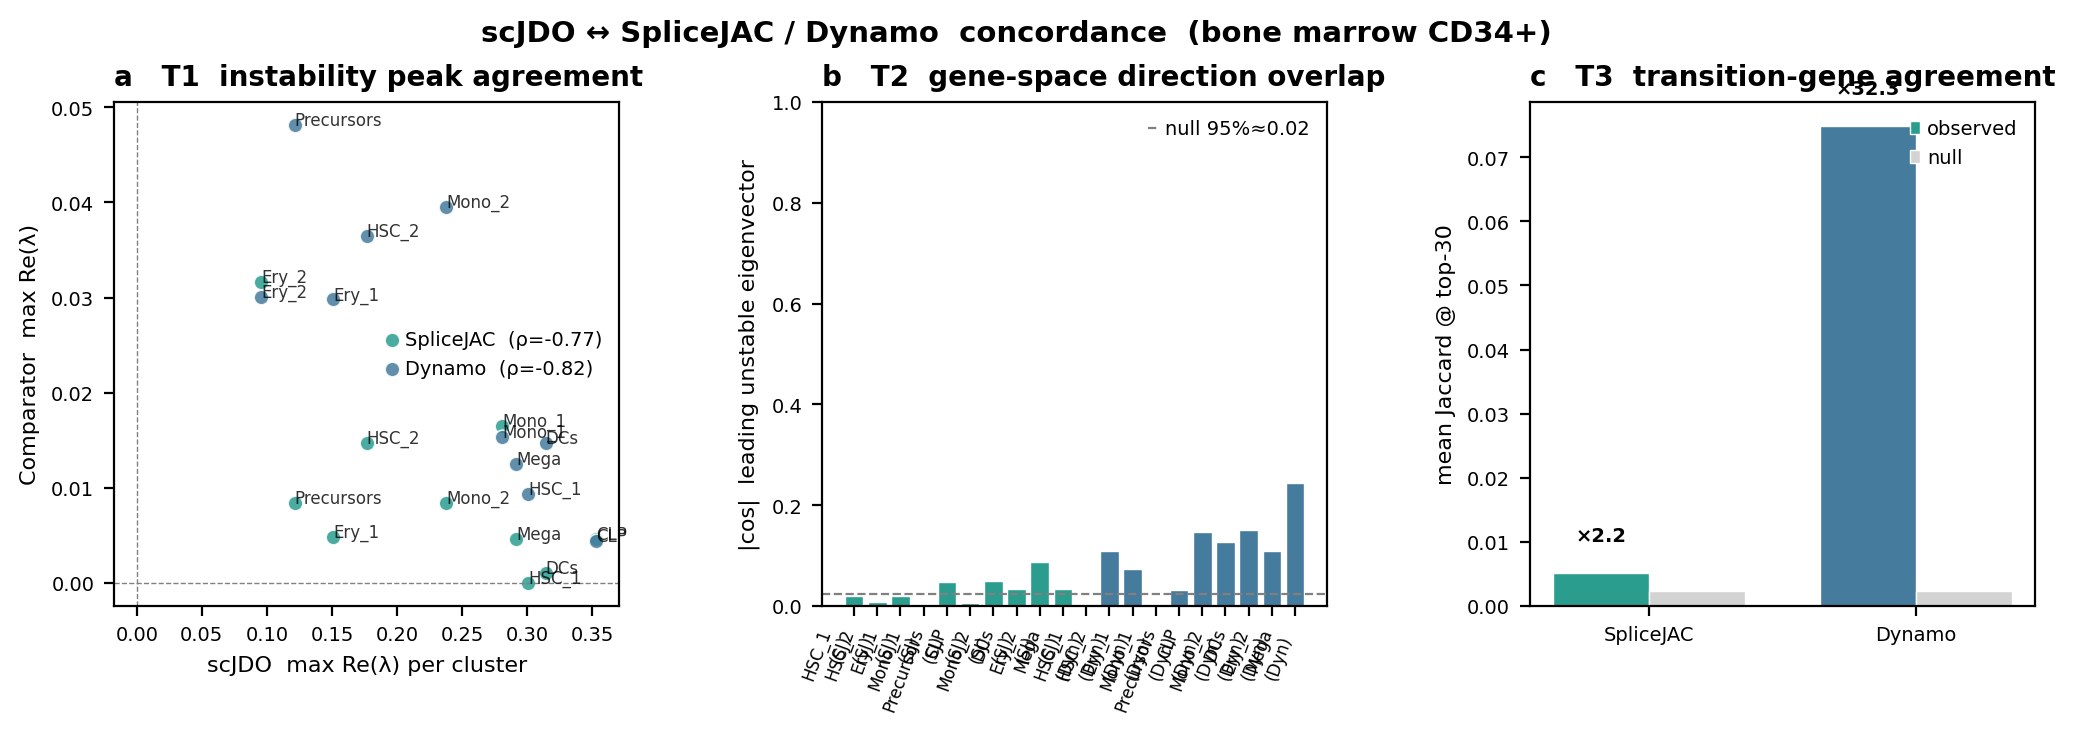

Saved → concordance_splicejac_dynamo.pdf


In [12]:
# ── 0. Sanity check before we draw — surface absent comparators ────
_any_t1 = bool(sjac_inst_per_cluster) or bool(dyn_inst_per_cluster)
_any_t2 = bool(t2_results.get('SpliceJAC')) or bool(t2_results.get('Dynamo'))
_any_t3 = bool(t3_results.get('SpliceJAC')) or bool(t3_results.get('Dynamo'))
if not (_any_t1 or _any_t2 or _any_t3):
    print('[concordance] Neither SpliceJAC nor Dynamo produced results. '
          'The figure will render an explanatory panel only — install both '
          'packages and re-run for the full concordance figure.')

fig = plt.figure(figsize=(10.5, 3.6))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.40,
                        left=0.07, right=0.985, top=0.88, bottom=0.18)
ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])
ax_c = fig.add_subplot(gs[0, 2])

# ── Panel a — T1 cluster-instability scatter
for label, dct, color in [
    ('SpliceJAC', sjac_inst_per_cluster, PALETTE['splicejac']),
    ('Dynamo',    dyn_inst_per_cluster,  PALETTE['dynamo']),
]:
    if not dct: continue
    keys, a, b = aligned_arrays(scjdo_inst_per_cluster, dct)
    rho, _ = spearmanr(a, b)
    ax_a.scatter(a, b, color=color, s=28, alpha=0.85, edgecolor='white', linewidth=0.6,
                  label=f'{label}  (ρ={rho:+.2f})')
    for k, x, y in zip(keys, a, b):
        ax_a.annotate(str(k), (x, y), fontsize=6, alpha=0.8)
ax_a.axhline(0, color='gray', lw=0.5, ls='--')
ax_a.axvline(0, color='gray', lw=0.5, ls='--')
ax_a.set_xlabel('scJDO  max Re(λ) per cluster')
ax_a.set_ylabel('Comparator  max Re(λ)')
ax_a.set_title('a   T1  instability peak agreement', fontweight='bold', loc='left')
ax_a.legend(frameon=False, loc='best')

# ── Panel b — T2 eigenvector |cos| per cluster (vs null)
bars, colors, labels = [], [], []
if t2_results.get('SpliceJAC'):
    for c, v in t2_results['SpliceJAC']['per_cluster'].items():
        bars.append(v); colors.append(PALETTE['splicejac']); labels.append(f'{c}\n(SJ)')
if t2_results.get('Dynamo'):
    for c, v in t2_results['Dynamo']['per_cluster'].items():
        bars.append(v); colors.append(PALETTE['dynamo']); labels.append(f'{c}\n(Dyn)')
if bars:
    ax_b.bar(np.arange(len(bars)), bars, color=colors, edgecolor='white', linewidth=0.5)
    ax_b.set_xticks(np.arange(len(bars)))
    ax_b.set_xticklabels(labels, rotation=70, ha='right', fontsize=6)
    null95 = max((t2_results.get('SpliceJAC') or {}).get('null_95', 0),
                  (t2_results.get('Dynamo') or {}).get('null_95', 0))
    if null95:
        ax_b.axhline(null95, color='gray', ls='--', lw=0.8, label=f'null 95%≈{null95:.2f}')
        ax_b.legend(frameon=False, loc='upper right')
ax_b.set_ylim(0, 1.0)
ax_b.set_ylabel('|cos|  leading unstable eigenvector')
ax_b.set_title('b   T2  gene-space direction overlap', fontweight='bold', loc='left')

# ── Panel c — T3 transition-gene Jaccard vs null
rows = []
if t3_results.get('SpliceJAC'):
    rows.append(('SpliceJAC', t3_results['SpliceJAC'], PALETTE['splicejac']))
if t3_results.get('Dynamo'):
    rows.append(('Dynamo',    t3_results['Dynamo'],    PALETTE['dynamo']))
if rows:
    xpos = np.arange(len(rows))
    means = [r[1]['mean_jaccard']   for r in rows]
    nulls = [r[1]['null_jaccard']   for r in rows]
    cols  = [r[2]                    for r in rows]
    ax_c.bar(xpos - 0.18, means, width=0.36, color=cols, label='observed',
              edgecolor='white', linewidth=0.5)
    ax_c.bar(xpos + 0.18, nulls, width=0.36, color='lightgray', label='null',
              edgecolor='white', linewidth=0.5)
    for x, r in zip(xpos, rows):
        ax_c.text(x - 0.18, r[1]['mean_jaccard'] + 0.005,
                   f"×{r[1]['fold_over_null']:.1f}",
                   ha='center', fontsize=7, fontweight='bold')
    ax_c.set_xticks(xpos)
    ax_c.set_xticklabels([r[0] for r in rows])
    ax_c.legend(frameon=False, loc='upper right')
ax_c.set_ylabel(f'mean Jaccard @ top-{TOP_K}')
ax_c.set_title('c   T3  transition-gene agreement', fontweight='bold', loc='left')

# Fallback notices if a panel has no data (so the PDF isn't blank)
if not _any_t1:
    ax_a.text(0.5, 0.5, 'No comparator results\n(install SpliceJAC/Dynamo)',
              ha='center', va='center', transform=ax_a.transAxes, fontsize=8,
              color=PALETTE['neutral'], style='italic')
if not _any_t2:
    ax_b.text(0.5, 0.5, 'No comparator results',
              ha='center', va='center', transform=ax_b.transAxes, fontsize=8,
              color=PALETTE['neutral'], style='italic')
if not _any_t3:
    ax_c.text(0.5, 0.5, 'No comparator results',
              ha='center', va='center', transform=ax_c.transAxes, fontsize=8,
              color=PALETTE['neutral'], style='italic')

fig.suptitle('scJDO ↔ SpliceJAC / Dynamo  concordance  (bone marrow CD34+)',
              fontsize=10.5, fontweight='bold', y=0.995)
fig_pdf = OUTDIR / 'concordance_splicejac_dynamo.pdf'
fig.savefig(fig_pdf, dpi=600, bbox_inches='tight')
fig.savefig(OUTDIR / 'concordance_splicejac_dynamo.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved → {fig_pdf}')

In [13]:
# ── 9. Export metrics for the rebuttal letter ──────────────────────────
summary = {
    'dataset':             'scvelo.datasets.bonemarrow (Setty 2019 CD34+)',
    'n_cells':             int(adata.n_obs),
    'n_genes':             int(adata.n_vars),
    'n_clusters':          int(len(clusters)),
    'scjdo_r2':            float(res['r2']),
    'have_splicejac':      HAVE_SPLICEJAC,
    'have_dynamo':         HAVE_DYNAMO,
    'T1_instability_peaks': t1_results,
    'T2_eigenvector_overlap': {k: {kk: vv for kk, vv in v.items() if kk != 'per_cluster'}
                                for k, v in t2_results.items()},
    'T3_transition_gene_lists': {k: {kk: vv for kk, vv in v.items() if kk != 'per_cluster_jaccard'}
                                  for k, v in t3_results.items()},
    'scjdo_inst_per_cluster':  {str(k): float(v) for k, v in scjdo_inst_per_cluster.items()},
    'splicejac_inst_per_cluster': {str(k): float(v) for k, v in sjac_inst_per_cluster.items()},
    'dynamo_inst_per_cluster': {str(k): float(v) for k, v in dyn_inst_per_cluster.items()},
}
(OUTDIR / 'concordance_metrics.json').write_text(json.dumps(summary, indent=2))
print(json.dumps(summary, indent=2))

{
  "dataset": "scvelo.datasets.bonemarrow (Setty 2019 CD34+)",
  "n_cells": 5780,
  "n_genes": 6482,
  "n_clusters": 10,
  "scjdo_r2": 0.9991003669013823,
  "have_splicejac": true,
  "have_dynamo": true,
  "T1_instability_peaks": {
    "SpliceJAC": {
      "n_clusters": 10,
      "spearman_rho": -0.7696969696969697,
      "spearman_p": 0.009221952722215994,
      "argmax_cluster_match": false,
      "scjdo_argmax": "CLP",
      "splicejac_argmax": "Ery_2"
    },
    "Dynamo": {
      "n_clusters": 10,
      "spearman_rho": -0.8181818181818182,
      "spearman_p": 0.0038149200825507135,
      "argmax_cluster_match": false,
      "scjdo_argmax": "CLP",
      "dynamo_argmax": "Precursors"
    }
  },
  "T2_eigenvector_overlap": {
    "SpliceJAC": {
      "mean_abs_cosine": 0.030492027019034685,
      "median_abs_cosine": 0.0265551193589395,
      "null_mean": 0.009812993651077908,
      "null_95": 0.024095319354892137,
      "frac_above_null_95": 0.5
    },
    "Dynamo": {
      "mean_abs

## Interpreting the result

**If T1 ρ ≥ 0.5, T2 mean |cos| > null 95% in a majority of clusters, T3 Jaccard ≥ 3× null:** report as concordance. Rebuttal sentence: *“On a splicing-amenable hematopoiesis dataset, the geometry-derived scJDO operator agrees with the splicing-derived operators of SpliceJAC and Dynamo on (i) which cluster is most unstable (Spearman ρ = …), (ii) the gene-space direction of the leading unstable mode (mean |cos| = …, p_null = …), and (iii) the resulting transition-gene lists (Jaccard@30 = …, ×… null). The temporal-tensor + archetype layer is a strict addition above this validated per-state Jacobian.”*

**If divergence:** point at the [Niemiec et al. 2025 benchmark](https://www.biorxiv.org/content/10.1101/2025.02.05.636568v1) showing splicing-derived Jacobians are themselves inconsistent, and cite the synthetic-double-well result (eigenvalue r = 0.758 vs analytic truth) as the gold-standard reference. The argument becomes: *“scJDO's operator is at least as well behaved as the prior single-cell Jacobian methods, and the temporal decomposition resolves structure unavailable to per-state snapshots.”*

Either way, this notebook produces the numbers that close the “is the operator real?” skepticism.